In [98]:
import uproot, numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
print(uproot.__version__)

5.7.5


In [99]:
def parse_trim(fname, ncols, x_scale=0.1, y_scale=0.01):
    """Parse a TRIM fixed-width table.
    Defaults convert depth Å -> nm (x0.1) and eV/(Å·ion) -> keV/(nm·ion) (x0.01).
    Column 0 gets x_scale; all remaining columns get y_scale."""
    rows = []
    with open(fname, encoding="latin-1") as fh:
        for line in fh:
            parts = line.replace(",", " ").split()
            try:
                vals = []
                for p in parts:
                    if "E" not in p.upper() and ("-" in p[1:] or "+" in p[1:]):
                        i = max(p.rfind("+"), p.rfind("-"))
                        p = p[:i] + "E" + p[i:]
                    vals.append(float(p))
                if len(vals) == ncols:
                    rows.append(vals)
            except ValueError:
                continue
    d = np.array(rows)
    d[:, 0]  *= x_scale
    d[:, 1:] *= y_scale
    return d

Fetch root file generated from manual scoring within carbon volume via the analysis manager

In [100]:
# Fetch
f = uproot.open("../target_run.root")          # adjust path to where the run wrote it
vals_MeV, edges_mm = f["EdepZ"].to_numpy()           # 300 bin contents [MeV], 301 edges [mm]

In [101]:
# Normalize per ion, N from the data (gated first entries), never a memorized constant
b = f["beam"].arrays(library="np")
m = (b["E"] > 20.0) & (np.abs(b["xp"]) < 5e-3) & (np.abs(b["yp"]) < 5e-3)      # first-entry gate [keV]
N = int(m.sum())

dEdep_keV   = vals_MeV * 1e3 / N                        # -> keV per ion per bin
centers  = 0.5 * (edges_mm[1:] + edges_mm[:-1]) * 1e6  # bin centers, mm -> nm

In [ ]:
# ---------- Mesh CSV ----------
d = np.loadtxt("../edep_mesh.csv", delimiter=",", comments="#")
# columns: iX, iY, depth, total(value)[keV], total(val^2), entries
depth    = d[:, 2].astype(int)
mesh_keV = (d[:, 3] / N)                               # already keV; per ion
order    = np.argsort(depth)                        # sort by depth
depth, mesh_keV = depth[order], mesh_keV[order]
mesh_z   = (depth + 0.5) * 0.5                       # voxel centers in nm (0.5 nm voxels)

In [103]:
# Per-voxel statistical error from the val^2 column
sum_v  = d[:, 3][order]
sum_v2 = d[:, 4][order]
n_ent  = d[:, 5][order]
with np.errstate(invalid="ignore", divide="ignore"):
    sigma = np.sqrt(np.maximum(sum_v2 - sum_v**2 / np.maximum(n_ent, 1), 0)) / N

Manual Scoring integral:   24.140 keV/ion
Mesh integral: 24.140 keV/ion
max |residual|: 0.0003 keV


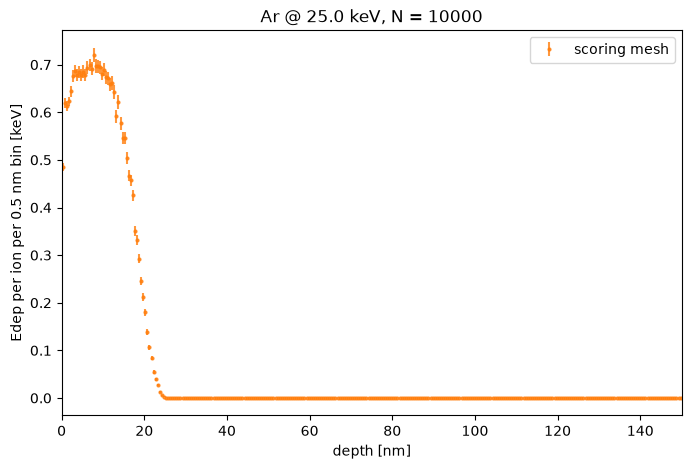

In [104]:
# ---------- Overlay ----------
fig, ax = plt.subplots(figsize=(8, 5))
#ax.plot(centers, dEdep_keV, label="manual scoring (SteppingAction)", color="C0")
ax.errorbar(mesh_z, mesh_keV, yerr=sigma, fmt=".", ms=4, color="C1",
            label="scoring mesh", alpha=0.8)
ax.set_xlabel("depth [nm]")
ax.set_ylabel("Edep per ion per 0.5 nm bin [keV]")
ax.set_xlim(0, 150)
ax.legend()
ax.set_title(f"Ar @ {b['E'][m].mean():.1f} keV, N = {N}")

# ---------- The quantitative verdict ----------
print(f"Manual Scoring integral:   {dEdep_keV.sum():.3f} keV/ion")
print(f"Mesh integral: {mesh_keV.sum():.3f} keV/ion")
resid = (dEdep_keV - mesh_keV)
print(f"max |residual|: {np.abs(resid).max():.4f} keV")


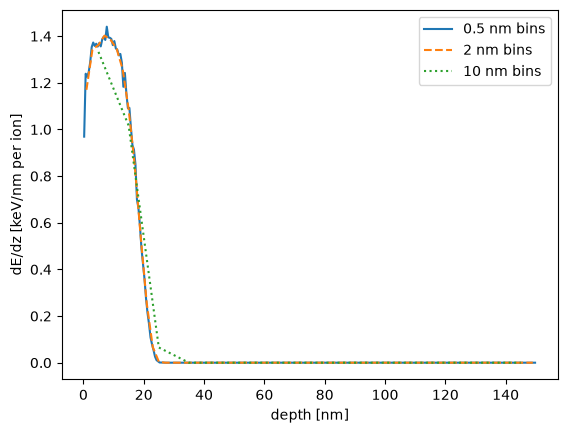

In [90]:
def rebin_density(values_keV, width_nm, k):
    """Merge k adjacent bins; return (centers_nm, density keV/nm)."""
    n = (len(values_keV) // k) * k
    merged = values_keV[:n].reshape(-1, k).sum(axis=1)      # contents ADD
    w = width_nm * k
    centers = (np.arange(len(merged)) + 0.5) * w
    return centers, merged / w                               # density = content / width

for k, style in [(1, "-"), (4, "--"), (20, ":")]:            # 0.5, 2, 10 nm bins
    c, d = rebin_density(mesh_keV, 0.5, k)
    plt.plot(c, d, style, label=f"{0.5*k:g} nm bins")
plt.xlabel("depth [nm]"); plt.ylabel("dE/dz [keV/nm per ion]"); plt.legend()

Scoring Run w/out voxel boundaries - checking 

Manual Scoring integral:   24.140 keV/ion


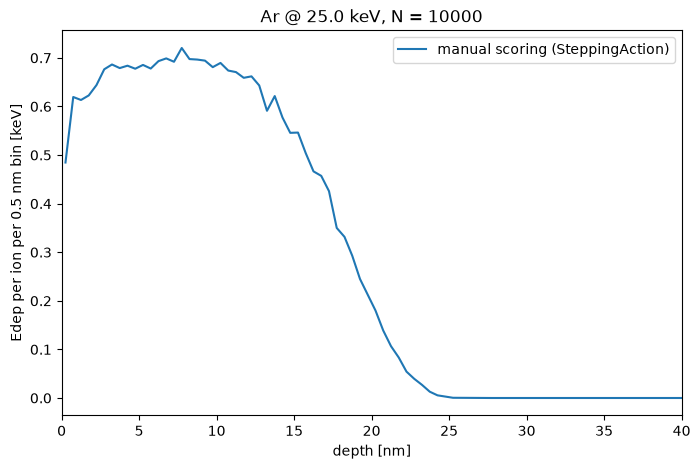

In [91]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(centers, dEdep_keV, label="manual scoring (SteppingAction)", color="C0")
ax.set_xlabel("depth [nm]")
ax.set_ylabel("Edep per ion per 0.5 nm bin [keV]")
ax.set_xlim(0, 40)
ax.legend()
ax.set_title(f"Ar @ {b['E'][m].mean():.1f} keV, N = {N}")

print(f"Manual Scoring integral:   {dEdep_keV.sum():.3f} keV/ion")

In [92]:
geantInput = {"x [mm]": (0, 0.5), "y [mm]": (0, 0.5),
       "xp [mrad]": (0.2, 0.1), "yp [mrad]": (0.2, 0.1),
       "E [keV]": (25.0, 0.25)}
data = {"x [mm]": b["x"][m], "y [mm]": b["y"][m],
        "xp [mrad]": b["xp"][m]*1e3, "yp [mrad]": b["yp"][m]*1e3,
        "E [keV]": b["E"][m]}
print(f"{'qty':10s} {'geantInput mu':>8s} {'geantInput sig':>8s} {'fit mu':>8s} {'fit sig':>8s}")
for k in geantInput:
    mu, sig = norm.fit(data[k])
    print(f"{k:10s} {geantInput[k][0]:8.3f} {geantInput[k][1]:8.3f} {mu:8.3f} {sig:8.3f}")

qty        geantInput mu geantInput sig   fit mu  fit sig
x [mm]        0.000    0.500   -0.005    0.500
y [mm]        0.000    0.500   -0.001    0.504
xp [mrad]     0.200    0.100    0.000    0.000
yp [mrad]     0.200    0.100    0.000    0.000
E [keV]      25.000    0.250   25.000    0.000


/home/abdulrahmen/projects/geant4-target/.venv/lib/python3.14/site-packages/scipy/stats/_distn_infrastructure.py:2079: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


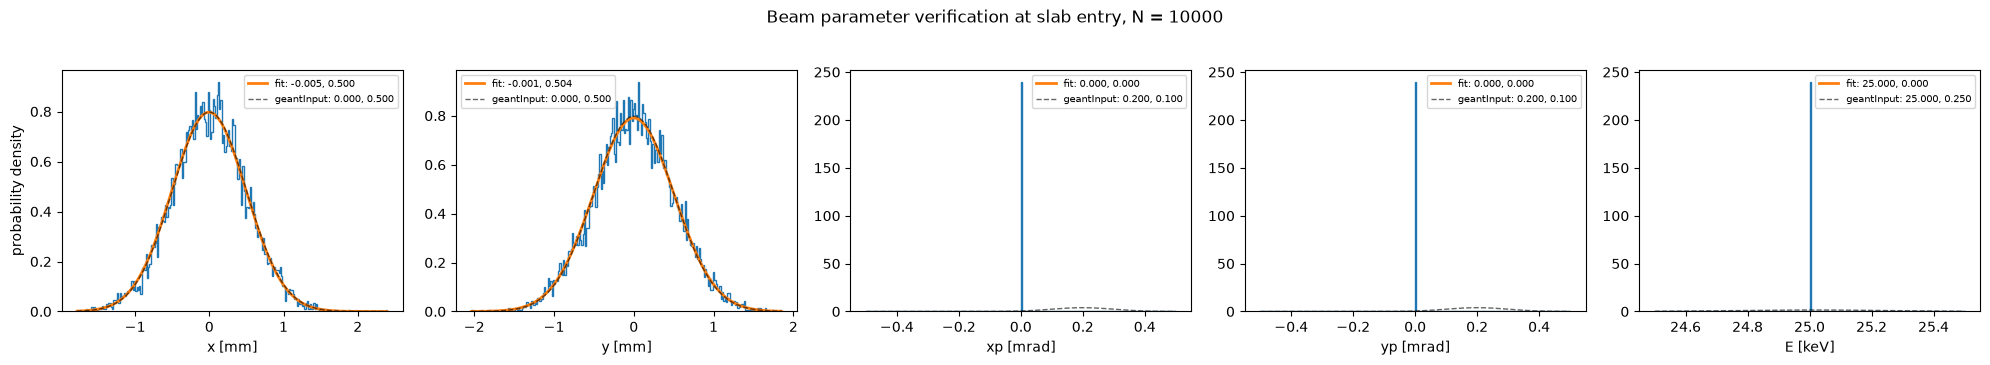

In [93]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, (k, (gmu, gsig)) in zip(axes, geantInput.items()):
    d = data[k]
    mu, sig = norm.fit(d)
    # histogram, density-normalized so the pdf overlays directly
    n, bins, _ = ax.hist(d, bins=240, density=True, histtype="step", color="C0")
    xs = np.linspace(bins[0], bins[-1], 300)
    ax.plot(xs, norm.pdf(xs, mu, sig), "C1-", lw=2,
            label=f"fit: {mu:.3f}, {sig:.3f}")
    ax.plot(xs, norm.pdf(xs, gmu, gsig), "k--", lw=1, alpha=0.6,
            label=f"geantInput: {gmu:.3f}, {gsig:.3f}")
    ax.set_xlabel(k)
    ax.legend(fontsize=7)
axes[0].set_ylabel("probability density")
fig.suptitle(f"Beam parameter verification at slab entry, N = {N}", y=1.03)
plt.tight_layout()

### TRIM Comparison

Energy To Recoils -> Nuclear Stopping/Elastic Interactions. Dominant Energy Loss Mechanism.

Peak unity conversion (TRIM $\text{eV}/\AA{}$) -> (Geant4 $\text{KeV}/\text{nm}$). Binning effect from Geant4 plot, take as rough sanity check not real validation

- Geant4 Peak: $~0.70 \text{KeV}/\text{nm}$ PER 0.5nm bins
- TRIM Peak: $~0.65 \text{KeV}/\text{nm}$

- Check TRIM process

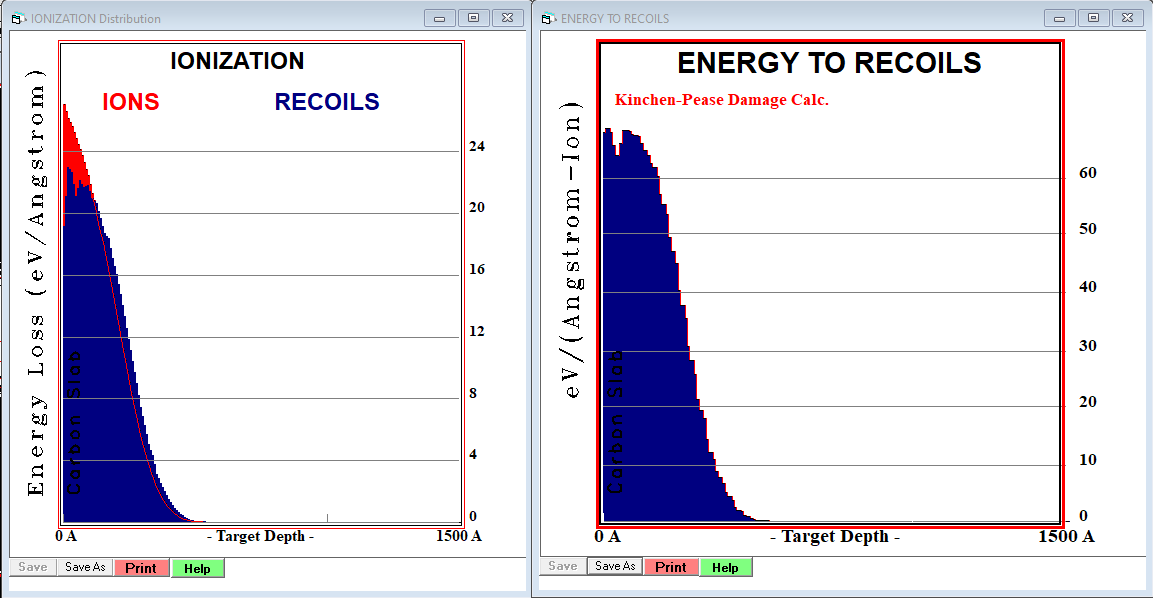
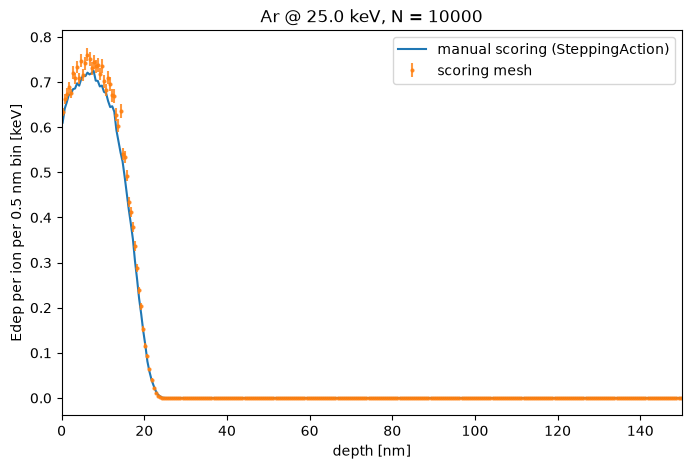


 ==================================================================
              SRIM version ---> SRIM-2013.00
              Calc. date   ---> July 12, 2026 
 ==================================================================

 Disk File Name = SRIM Outputs\Argon in Carbon.txt

 Ion = Argon [18] , Mass = 39.962 amu

 Target Density =  1.9000E+00 g/cm3 = 9.5261E+22 atoms/cm3
 ======= Target  Composition ========
    Atom   Atom   Atomic    Mass     
    Name   Numb   Percent   Percent  
    ----   ----   -------   -------  
      C      6    100.00    100.00   
 ====================================
 Bragg Correction = 0.00%
 Stopping Units =  keV / micron   
 See bottom of Table for other Stopping units 

        Ion        dE/dx      dE/dx     Projected  Longitudinal   Lateral
       Energy      Elec.      Nuclear     Range     Straggling   Straggling
  --------------  ---------- ---------- ----------  ----------  ----------
  25.00 keV   2.731E+02  6.726E+02     285 A        71 A        57 A   
-----------------------------------------------------------
 Multiply Stopping by        for Stopping Units
 -------------------        ------------------
  1.0000E-01                 eV / Angstrom 
  1.0000E+00                keV / micron   
  1.0000E+00                MeV / mm       
  5.2633E-03                keV / (ug/cm2) 
  5.2633E-03                MeV / (mg/cm2) 
  5.2633E+00                keV / (mg/cm2) 
  1.0497E-01                 eV / (1E15 atoms/cm2)
  4.7643E-04                L.S.S. reduced units
 ==================================================================
 (C) 1984,1989,1992,1998,2008 by J.P. Biersack and J.F. Ziegler

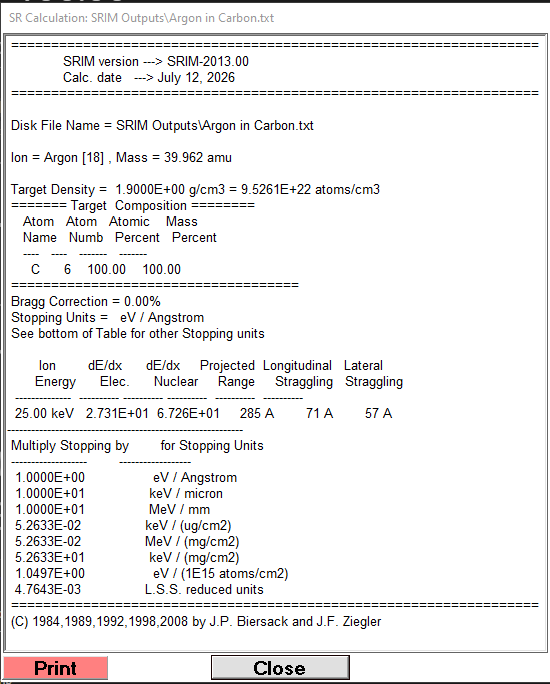

Carbon density in both -> $1.9 \text{g / cm}^3$

SRIM Stopping Power:

$(dE/dx)|_{E} = 0.2731 \text{KeV/nm}$

$(dE/dx)|_{N} = 0.6726 \text{KeV/nm}$

GEANT4 Stopping Power From EMCalculator

$(dE/dx)|_{E} = 0.210 \text{KeV/nm}$

$(dE/dx)|_{N} = 0.699 \text{KeV/nm}$

## Trim Analysis By Process

In [94]:
ioniz_path = "../data/TRIM/IONIZ.txt"
phonon_path = "../data/TRIM/PHONON.txt"
e2recoil_path = "../data/TRIM/E2RECOIL.txt"

ioniz_data = parse_trim(ioniz_path, 3)
phono_data = parse_trim(phonon_path, 3)
e2recoil_data = parse_trim(e2recoil_path, 3)

IONIZ ions                5.61 keV/ion
IONIZ recoils             7.77 keV/ion
PHONON total             11.32 keV/ion
TRIM total               24.70 keV/ion
E2RECOIL (transfer)      18.70 keV/ion
TRIM total integral: 24.695 keV/ion
Geant4 total integral: 24.140 keV/ion


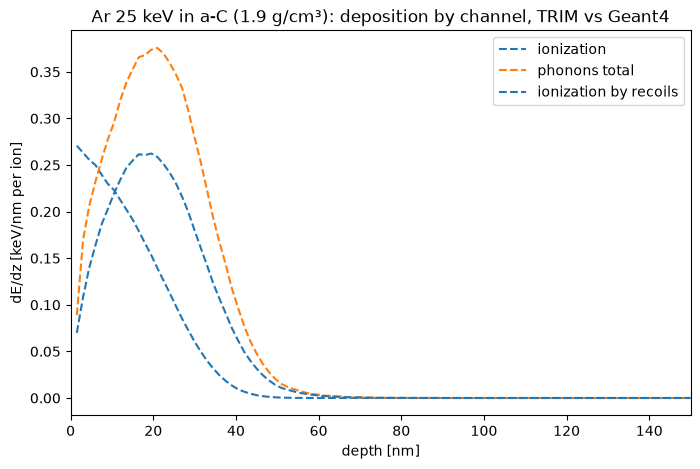

In [97]:
z = ioniz_data[:, 0]   # all three files share the same depth grid; verify once:
assert np.allclose(z, phono_data[:, 0]) and np.allclose(z, e2recoil_data[:, 0])

# --- Channels (dissipation ledger) ---
ioniz_ions    = ioniz_data[:, 1]
ioniz_recoils = ioniz_data[:, 2]
phonon_total  = phono_data[:, 1] + phono_data[:, 2]

# --- TRIM total deposition: all dissipation, no E2RECOIL (transfer ledger!) ---
trim_total = ioniz_ions + ioniz_recoils + phonon_total

# --- Integral checks before trusting any of it ---
dz = np.diff(z).mean()
for name, curve in [("IONIZ ions", ioniz_ions), ("IONIZ recoils", ioniz_recoils),
                    ("PHONON total", phonon_total), ("TRIM total", trim_total),
                    ("E2RECOIL (transfer)", e2recoil_data[:, 1])]:
    print(f"{name:22s} {np.sum(curve)*dz:7.2f} keV/ion")
# expect: total ~= 25 minus backscatter leakage; E2RECOIL ~= 18.6;
# and IONIZ_recoils + PHONON_recoils ~= E2RECOIL (the ledger balance)

# --- Plot: stacked channels + total, then the Geant4 overlay ---
fig, ax = plt.subplots(figsize=(8, 5))
#ax.stackplot(z, ioniz_ions, ioniz_recoils, phonon_total,
#             labels=["ionization (by ions)", "ionization (by recoils)", "phonons"],
#             alpha=0.55)
#ax.plot(z, ioniz_ions + ioniz_recoils + phonon_total, "k-", lw=1.5, label="TRIM total")
ax.plot(z, ioniz_ions, "C0--", lw=1.5, label="ionization")
ax.plot(z, phonon_total, "C1--", lw=1.5, label="phonons total")
ax.plot(z, ioniz_recoils, "C0--", lw=1.5, label="ionization by recoils")
#ax.plot(z, trim_total, "k-", lw=1.5, label="TRIM total")

# Geant4 mesh as density, from your existing arrays:
#ax.plot(mesh_z, mesh_keV / 0.5, "C3--", lw=2, label="Geant4 total (mesh)")

ax.set_xlabel("depth [nm]")
ax.set_ylabel("dE/dz [keV/nm per ion]")
ax.set_xlim(0, 150)
ax.legend()
ax.set_title("Ar 25 keV in a-C (1.9 g/cm³): deposition by channel, TRIM vs Geant4")

print(f"TRIM total integral: {trim_total.sum()*dz:.3f} keV/ion")
print(f"Geant4 total integral: {mesh_keV.sum():.3f} keV/ion")